In [ ]:
!pip install upsetplot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=6c37fb900954f4bf221efe5e8e6cd50cebe0267485814adb072fd7859606e9a0
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import re
from difflib import SequenceMatcher
from pathlib import Path
from matplotlib.ticker import MaxNLocator
from upsetplot import UpSet, from_indicators
import warnings
import re
warnings.filterwarnings("ignore", category=FutureWarning)#ignore warnind

drive.mount('/content/drive')
#os.listdir("/content/drive/MyDrive/estudos_snowbaling")
#base = "/content/drive/MyDrive/estudos_snowbaling"


Mounted at /content/drive


In [ ]:
#os.listdir("/content/drive/MyDrive/estudos_snowbaling")
#base = "/content/drive/MyDrive/estudos_snowbaling"


In [ ]:
BASE = Path(".")
CSV_BASE = BASE / "extended_tool_analisy" / "CSVs"

DEF FUNCTION NORMALIZATION AND MATCH

In [ ]:
from pathlib import Path
from typing import Optional
import ast
import re
from difflib import SequenceMatcher

import pandas as pd


TOOL_ALIASES = {
    "googleacademico": "googlescholar",
    "googlescholar": "googlescholar",
    "google scholar": "googlescholar",
    "lens": "lens",
    "litmaps": "litmaps",
    "litmap": "litmaps",
    "researchrabbit": "researchrabbit",
    "semanticscholar": "semanticscholar",
    "semantic scholar": "semanticscholar",
    "openalex": "openalex",
    "opencitations": "opencitations",
    "snowmap": "snowmap",
    "our_tool": "snowmap",
    "Our_tool": "snowmap",
    "Snowmap": "snowmap",
}


ALL_TOOLS = [
    "googlescholar",
    "lens",
    "litmaps",
    "researchrabbit",
    "semanticscholar",
    "openalex",
    "opencitations",
    "snowmap",
]

DOI_COL_CANDIDATES = [
    "doi",
    "DOI",
    "doi_norm",
    "document_doi",
    "paper_doi",
    "work_doi",
    "doi_url",
    "doi link",
    "citing",
    "externalIds",  # Semantic Scholar
]

TITLE_COL_CANDIDATES = [
    "title",
    "Title",
    "paper_title",
    "document_title",
    "article_title",
    "display_name",
    "work_title",
    "titulo",
    "paper title",
]


# =========================================================
# NORMALIZATION
# =========================================================

def normalize_doi(value) -> Optional[str]:
    if pd.isna(value):
        return None

    s = str(value).strip().lower()
    if s in {"", "nan", "none", "null", "x"}:
        return None

    s = s.replace("https://doi.org/", "")
    s = s.replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "")
    s = s.replace("http://dx.doi.org/", "")
    s = s.replace("doi.org/", "")
    s = s.replace("doi:", "")
    s = s.strip()

    m = re.search(r"(10\.\S+)", s)
    if not m:
        return None

    return m.group(1).rstrip(" .;,)") or None


def normalize_title(value) -> str:
    if pd.isna(value):
        return ""

    s = str(value).strip().lower()
    if s in {"", "nan", "none", "null"}:
        return ""

    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s.strip()


def fuzzy_match_score(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()


# =========================================================
# SEMANTIC SCHOLAR externalIds
# =========================================================


def extract_doi_from_externalids(value):
    if pd.isna(value):
        return None

    # caso já venha como dict
    if isinstance(value, dict):
        return normalize_doi(value.get("DOI") or value.get("doi"))

    s = str(value).strip()

    if s in {"", "nan", "none", "null", "x"}:
        return None

    # tenta interpretar como dict em string
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, dict):
            return normalize_doi(parsed.get("DOI") or parsed.get("doi"))
    except Exception:
        pass

    # fallback: regex direto no texto
    m = re.search(r"(10\.\S+)", s.lower())
    if m:
        return normalize_doi(m.group(1))

    return None


# =========================================================
# YEAR RULES
# =========================================================

def slr_year_rule(slr: str):
    s = str(slr).lower()

    if "new_csvs_slr01" in s:
        return (None, 2025, "le")
    if "seed_studies02" in s:
        return (2003, 2015, "range")
    if "seed_studies03" in s:
        return (None, 2015, "le")
    if "seed_studies04" in s:
        return (None, 2025, "le")

    return (None, None, None)


def tool_year_column(tool: str) -> Optional[str]:
    t = (tool or "").lower()

    if t in {"snowmap", "googlescholar", "litmaps", "researchrabbit"}:
        return "Year"
    if t == "lens":
        return "Publication Year"
    if t == "openalex":
        return "publication_year"
    if t == "opencitations":
        return "creation"
    if t == "semanticscholar":
        return "year"

    return None


def extract_year_series(series: pd.Series) -> pd.Series:
    y = pd.to_numeric(series, errors="coerce")

    mask_nan = y.isna()
    if mask_nan.any():
        s = series.astype(str)
        yr = s.str.extract(r"((?:19|20)\d{2})", expand=False)
        y.loc[mask_nan] = pd.to_numeric(yr.loc[mask_nan], errors="coerce")

    return y.round().astype("Int64")


def filter_by_year_rules(df: pd.DataFrame, slr: str, tool: str) -> pd.DataFrame:
    if (tool or "").lower() == "relevantes":
        return df

    min_y, max_y, mode = slr_year_rule(slr)
    if mode is None:
        return df

    col = tool_year_column(tool)
    if not col or col not in df.columns:
        return df

    out = df.copy()
    out["_year_norm"] = extract_year_series(out[col])

    if mode == "le":
        out = out[out["_year_norm"].notna() & (out["_year_norm"] <= max_y)]
    elif mode == "range":
        out = out[
            out["_year_norm"].notna()
            & (out["_year_norm"] >= min_y)
            & (out["_year_norm"] <= max_y)
        ]
    elif mode == "eq":
        out = out[out["_year_norm"].notna() & (out["_year_norm"] == min_y)]

    return out.drop(columns=["_year_norm"])


# =========================================================
# COLUMN DETECTION
# =========================================================

def find_first_matching_column(df: pd.DataFrame, candidates) -> Optional[str]:
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None


def find_doi_column(df: pd.DataFrame) -> Optional[str]:
    col = find_first_matching_column(df, DOI_COL_CANDIDATES)
    if col:
        return col

    for c in df.columns:
        if "doi" in c.lower():
            return c
    return None


def find_title_column(df: pd.DataFrame) -> Optional[str]:
    col = find_first_matching_column(df, TITLE_COL_CANDIDATES)
    if col:
        return col

    for c in df.columns:
        cl = c.lower()
        if "title" in cl or "titulo" in cl:
            return c
    return None


# =========================================================
# TOOL DETECTION
# =========================================================

def detect_tool_from_filename(path: Path) -> Optional[str]:
    s = path.stem.lower()
    for alias, canonical in TOOL_ALIASES.items():
        if alias in s:
            return canonical
    return None


def resolve_slr_name(csv_path: Path) -> str:
    parent = csv_path.parent.name
    grandparent = csv_path.parent.parent.name

    if "seed_studies" in parent.lower() or "new_csvs_slr" in parent.lower():
        return parent
    return grandparent


# =========================================================
# PREPARE DATAFRAME
# =========================================================

def prepare_matching_dataframe(df: pd.DataFrame, tool: Optional[str] = None) -> pd.DataFrame:
    out = df.copy()
    out.columns = [c.strip() for c in out.columns]

    title_col = find_title_column(out)
    doi_col = find_doi_column(out)

    out["doi_norm"] = None

    if tool == "semanticscholar":
        cols_lower = {c.lower(): c for c in out.columns}

        if "externalids" in cols_lower:
            real_col = cols_lower["externalids"]
            out["doi_norm"] = out[real_col].apply(extract_doi_from_externalids)
        elif doi_col:
            out["doi_norm"] = out[doi_col].apply(normalize_doi)
    else:
        if doi_col:
            out["doi_norm"] = out[doi_col].apply(normalize_doi)

    if title_col:
        out["title_norm"] = out[title_col].apply(normalize_title)
    else:
        out["title_norm"] = ""

    out["uid"] = out["doi_norm"]
    missing_uid = out["uid"].isna() | (out["uid"] == "")
    out.loc[missing_uid, "uid"] = out.loc[missing_uid, "title_norm"]

    out = out[(out["doi_norm"].notna()) | (out["title_norm"] != "")].copy()

    return out


# =========================================================
# LOAD GT
# =========================================================

def load_ground_truth(gt_path: Path) -> pd.DataFrame:
    gt = pd.read_csv(gt_path)
    gt.columns = [c.strip() for c in gt.columns]
    gt = prepare_matching_dataframe(gt, tool=None)
    return gt.reset_index(drop=True)


# =========================================================
# READ TOOL RECORDS
# =========================================================

def read_tool_records(csv_path: Path) -> pd.DataFrame:
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        #print(f"Erro ao ler {csv_path}: {e}")
        return pd.DataFrame(columns=["doi_norm", "title_norm", "uid"])

    df.columns = [c.strip() for c in df.columns]

    tool = detect_tool_from_filename(csv_path)
    slr = resolve_slr_name(csv_path)

    before = len(df)

    if tool:
        df = filter_by_year_rules(df, slr=slr, tool=tool)

    after_filter = len(df)

    df = prepare_matching_dataframe(df, tool=tool)

    #print(
     #   f"{csv_path.name} | tool={tool} | slr={slr} | "
      #  f"before={before} | after_filter={after_filter} | after_prepare={len(df)}"
    #)

    return df


# =========================================================
# MATCH GT vs TOOL
# =========================================================

def match_gt_against_tool(
    gt_df: pd.DataFrame,
    tool_df: pd.DataFrame,
    threshold: float = 0.90
) -> pd.DataFrame:
    gt = gt_df.copy()
    tool = tool_df.copy()

    gt["title_norm"] = gt["title_norm"].fillna("")
    tool["title_norm"] = tool["title_norm"].fillna("")

    match_doi = [False] * len(gt)
    match_title = [False] * len(gt)
    found = [False] * len(gt)

    # ---------------------------------
    # DOI exact match
    # ---------------------------------
    tool_dois = set(tool["doi_norm"].dropna())

    for i, row in gt.iterrows():
        doi = row["doi_norm"]
        if pd.notna(doi) and doi in tool_dois:
            match_doi[i] = True
            found[i] = True

    # ---------------------------------
    # Fuzzy title match (1:1)
    # ---------------------------------
    tool_remaining = tool.copy()
    used_tool_idx = set()

    for i, row in gt.iterrows():
        if found[i]:
            continue

        gtitle = row["title_norm"]
        if not gtitle:
            continue

        best_score = -1.0
        best_j = None

        for j, trow in tool_remaining.iterrows():
            if j in used_tool_idx:
                continue

            ttitle = trow["title_norm"]
            if not ttitle:
                continue

            score = fuzzy_match_score(gtitle, ttitle)

            if score > best_score:
                best_score = score
                best_j = j

        if best_j is not None and best_score >= threshold:
            match_title[i] = True
            found[i] = True
            used_tool_idx.add(best_j)

    return pd.DataFrame(
        {
            "match_doi": match_doi,
            "match_title": match_title,
            "found": found
        },
        index=gt.index
    )


# =========================================================
# ANALYZE FOLDER
# =========================================================

def analyze_csv_folder(folder_path: Path, gt_df: pd.DataFrame, verbose: bool = False):
    results_by_tool = {}
    summary_rows = []

    for csv_path in sorted(folder_path.glob("*.csv")):
        tool = detect_tool_from_filename(csv_path)

        if tool is None:
            #if verbose:
                #print(f"{folder_path.name} | {csv_path.name} | tool não reconhecido")
            continue

        if tool not in ALL_TOOLS:
            #if verbose:
                #print(f"{folder_path.name} | {csv_path.name} | tool={tool} fora de ALL_TOOLS")
            continue

        tool_df = read_tool_records(csv_path)
        match_df = match_gt_against_tool(gt_df, tool_df)

        results_by_tool[tool] = match_df["found"].tolist()

        n_doi = int(match_df["match_doi"].sum())
        n_title = int(match_df["match_title"].sum())
        n_found = int(match_df["found"].sum())

        summary_rows.append({
            "folder": folder_path.name,
            "file": csv_path.name,
            "tool": tool,
            "gt_total": len(gt_df),
            "tool_total_raw": len(tool_df),
            "match_doi": n_doi,
            "match_title_only": n_title,
            "match_total": n_found
        })

        #if verbose:
            #print(
            #    f"{folder_path.name} | {csv_path.name} | tool={tool} | "
             #   f"doi_csv={tool_df['doi_norm'].dropna().shape[0]} | "
             #   f"title_csv={tool_df['title_norm'].replace('', pd.NA).dropna().shape[0]} | "
             #   f"match_doi={n_doi} | match_title_only={n_title} | total={n_found}"
           # )

    presence = {}
    for tool in ALL_TOOLS:
        presence[tool] = results_by_tool.get(tool, [False] * len(gt_df))

    index_labels = []
    for _, row in gt_df.iterrows():
        label = row["doi_norm"] if pd.notna(row["doi_norm"]) else row["title_norm"]
        index_labels.append(label)

    presence_df = pd.DataFrame(presence, index=index_labels)
    presence_df.index.name = "gt_record"

    summary_df = pd.DataFrame(summary_rows)
    return presence_df, summary_df


# =========================================================
# RUNNERS
# =========================================================

def run_slr01(root_path: Path, gt_filename: str, verbose: bool = False):
    gt_path = root_path / gt_filename
    gt_df = load_ground_truth(gt_path)
    presence_df, summary_df = analyze_csv_folder(root_path, gt_df, verbose=verbose)
    return gt_df, presence_df, summary_df


def run_slr_seed_structure(root_path: Path, gt_filename: str, verbose: bool = False):
    gt_path = root_path / gt_filename
    gt_df = load_ground_truth(gt_path)

    seed_dirs = sorted([
        p for p in root_path.iterdir()
        if p.is_dir() and p.name.lower().startswith("artigo")
    ])

    presence_by_seed = {}
    summary_list = []

    for seed_dir in seed_dirs:
        presence_df, summary_df = analyze_csv_folder(seed_dir, gt_df, verbose=verbose)
        presence_by_seed[seed_dir.name] = presence_df

        if not summary_df.empty:
            summary_df["seed"] = seed_dir.name
            summary_list.append(summary_df)

    summary_all = pd.concat(summary_list, ignore_index=True) if summary_list else pd.DataFrame()

    return gt_df, presence_by_seed, summary_all

DEF function for graph

In [ ]:
from typing import Optional

def upset_from_global_presence(
    global_presence: pd.DataFrame,
    title: str = "",
    out_png: Optional[str] = None
) -> None:

    tools = list(ALL_TOOLS)

    #map names
    alias_map = {
        "google scholar": "googlescholar",
        "google_scholar": "googlescholar",
        "googlescholar": "googlescholar",

        "semantic scholar": "semanticscholar",
        "semantic_scholar": "semanticscholar",
        "semanticscholar": "semanticscholar",

        "research rabbit": "researchrabbit",
        "research_rabbit": "researchrabbit",
        "researchrabbit": "researchrabbit",

        "open alex": "openalex",
        "open_alex": "openalex",
        "openalex": "openalex",

        "open citations": "opencitations",
        "open_citations": "opencitations",
        "opencitations": "opencitations",

        "litmaps": "litmaps",
        "litmap": "litmaps",
        "lens": "lens",
        "nossatool": "snowmap",
        "our tool": "snowmap",
        "our_tool": "snowmap",
        "ourtool": "snowmap",
        "snowmap": "snowmap",
        "Snowmap": "snowmap",
        "snowmap_tool": "snowmap",
    }

    def normalize_col_name(name: str) -> str:
        s = str(name).strip().lower()
        s = s.replace(".csv", "")
        s = s.replace("-", " ")
        s = s.replace("_", " ")
        s = " ".join(s.split())
        return alias_map.get(s, s.replace(" ", ""))

#new name
    gp = global_presence.copy()
    gp = gp.rename(columns={c: normalize_col_name(c) for c in gp.columns})

    #duplicate
    if gp.columns.duplicated().any():
        gp = gp.T.groupby(level=0).max().T

#check tools
    for t in tools:
        if t not in gp.columns:
            gp[t] = False

    indicator_df = gp[tools].fillna(False).astype(bool)
    N_GT = len(indicator_df)

    upset_data = from_indicators(tools, indicator_df)

    fig = plt.figure(figsize=(12, 6))

    u = UpSet(
        upset_data,
        subset_size="count",
        show_counts=None,
        show_percentages=None,
        sort_by="degree",
    )
    u.plot(fig=fig)

#intersection bars (top)

    ax_inter = next(
        ax for ax in fig.axes
        if "intersection" in (ax.get_ylabel() or "").lower()
    )

    ax_inter.yaxis.set_major_locator(MaxNLocator(integer=True))

    inter_bars = [p for p in ax_inter.patches if p.get_height() > 0]

    if inter_bars:
        ymax = max(b.get_height() for b in inter_bars)
        ax_inter.set_ylim(0, ymax * 1.6)

    ax_inter.set_xlim(-1.0, len(inter_bars) if inter_bars else 1)

    new_w = 0.25
    for b in inter_bars:
        old_w = b.get_width()
        b.set_x(b.get_x() + (old_w - new_w) / 2)
        b.set_width(new_w)

    used = {}
    for b in inter_bars:
        h = b.get_height()
        x = b.get_x() + b.get_width() / 2

        key = int(round(h))
        k = used.get(key, 0)
        used[key] = k + 1

        ax_inter.annotate(
            f"{(h / N_GT):.1%}",
            (x, h),
            xytext=(0, 8 + 12 * k),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            clip_on=False,
            zorder=10
        )

#layout

    if title:
        fig.suptitle(title, y=0.98)

    fig.subplots_adjust(left=0.22, right=0.98, top=0.90, bottom=0.18)

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")

    plt.show()

### **ARTIGO 02**

In [ ]:
#ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/CSVs gerados pelas plataformas/new_csvs_slr02/seed_studies02")
#ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/new_csvs_slr02/seed_studies02")
ROOT = CSV_BASE / "new_csvs_slr02/seed_studies02"

gt_df_slr2, presence_by_seed_slr2, summary_slr2 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo02.csv",
    verbose=True
)

display(gt_df_slr2.head())
display(summary_slr2)
display(presence_by_seed_slr2["artigo01_02"])
display(presence_by_seed_slr2["artigo02_02"])
display(presence_by_seed_slr2["artigo03_02"])
display(presence_by_seed_slr2["artigo04_02"])
display(presence_by_seed_slr2["artigo05_02"])
display(presence_by_seed_slr2["artigo06_02"])
display(presence_by_seed_slr2["artigo07_02"])
display(presence_by_seed_slr2["artigo08_02"])

,Title,Unnamed: 1,doi_norm,title_norm,uid
0,An ontology for guiding performance testing,10.1109/wi-iat.2014.62,None,an ontology for guiding performance testing,an ontology for guiding performance testing
1,A knowledge management analysis of an in-house...,NaN,None,a knowledge management analysis of an inhouse ...,a knowledge management analysis of an inhouse ...
2,Using ontology patterns for building a referen...,10.1109/EDOCW.2013.10,None,using ontology patterns for building a referen...,using ontology patterns for building a referen...
3,Using ontology to generate test cases for GUI ...,doi.org/10.1504/IJCAT.2011.045407,None,using ontology to generate test cases for gui ...,using ontology to generate test cases for gui ...
4,Maturing software engineering knowledge throug...,10.1109/TSE.2009.13,None,maturing software engineering knowledge throug...,maturing software engineering knowledge throug...


,folder,file,tool,gt_total,tool_total_raw,match_doi,match_title_only,match_total,seed
0,artigo01_02,googleAcademico.csv,googlescholar,5,8,0,0,0,artigo01_02
1,artigo01_02,lens.csv,lens,5,7,0,0,0,artigo01_02
2,artigo01_02,litmaps.csv,litmaps,5,7,0,0,0,artigo01_02
3,artigo01_02,openAlex.csv,openalex,5,6,0,0,0,artigo01_02
4,artigo01_02,opencitations.csv,opencitations,5,3,0,0,0,artigo01_02
...,...,...,...,...,...,...,...,...,...
56,artigo08_02,openAlex.csv,openalex,5,12,0,0,0,artigo08_02
57,artigo08_02,opencitations.csv,opencitations,5,2,0,0,0,artigo08_02
58,artigo08_02,our_tool.csv,snowmap,5,14,0,1,1,artigo08_02
59,artigo08_02,researchRabbit.csv,researchrabbit,5,14,0,1,1,artigo08_02


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
using ontology patterns for building a reference software testing ontology,False,False,False,False,False,False,False,False
using ontology to generate test cases for gui testing,False,False,False,False,False,False,False,False
maturing software engineering knowledge through classifications a case study on unit testing techniques,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
using ontology patterns for building a reference software testing ontology,False,False,False,False,False,False,False,False
using ontology to generate test cases for gui testing,False,False,False,False,False,False,False,False
maturing software engineering knowledge through classifications a case study on unit testing techniques,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
using ontology patterns for building a reference software testing ontology,False,False,False,False,False,False,False,False
using ontology to generate test cases for gui testing,False,False,False,False,False,False,False,False
maturing software engineering knowledge through classifications a case study on unit testing techniques,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
using ontology patterns for building a reference software testing ontology,False,False,False,False,False,False,False,False
using ontology to generate test cases for gui testing,False,False,False,False,False,False,False,False
maturing software engineering knowledge through classifications a case study on unit testing techniques,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
using ontology patterns for building a reference software testing ontology,False,False,False,False,False,False,False,False
using ontology to generate test cases for gui testing,False,False,False,False,False,False,False,False
maturing software engineering knowledge through classifications a case study on unit testing techniques,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,True,True,True,True,False,True,False,True
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
using ontology patterns for building a reference software testing ontology,False,False,False,False,False,False,False,False
using ontology to generate test cases for gui testing,False,False,False,False,False,False,False,False
maturing software engineering knowledge through classifications a case study on unit testing techniques,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,False,False,False,False,True,False,False,False
a knowledge management analysis of an inhouse manual software testing,False,False,False,False,False,False,False,False
using ontology patterns for building a reference software testing ontology,False,False,False,False,False,False,False,False
using ontology to generate test cases for gui testing,False,False,False,False,False,False,False,False
maturing software engineering knowledge through classifications a case study on unit testing techniques,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,False,False,False,False,False,False,False,False
a knowledge management analysis of an inhouse manual software testing,True,True,True,True,True,False,False,True
using ontology patterns for building a reference software testing ontology,False,False,False,False,False,False,False,False
using ontology to generate test cases for gui testing,False,False,False,False,False,False,False,False
maturing software engineering knowledge through classifications a case study on unit testing techniques,False,False,False,False,False,False,False,False


In [ ]:
global_presence_slr2 = None

for seed, df in presence_by_seed_slr2.items():
    df_bin = df[ALL_TOOLS].astype(bool)
    global_presence_slr2 = df_bin.copy() if global_presence_slr2 is None else (global_presence_slr2 | df_bin)

global_presence_slr2 = global_presence_slr2.astype(int)
display(global_presence_slr2)

,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
an ontology for guiding performance testing,1,1,1,1,1,1,0,1
a knowledge management analysis of an inhouse manual software testing,1,1,1,1,1,0,0,1
using ontology patterns for building a reference software testing ontology,0,0,0,0,0,0,0,0
using ontology to generate test cases for gui testing,0,0,0,0,0,0,0,0
maturing software engineering knowledge through classifications a case study on unit testing techniques,0,0,0,0,0,0,0,0


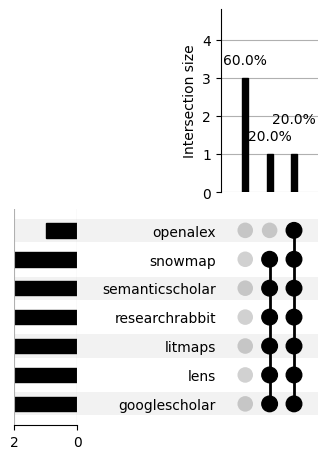

In [ ]:
upset_from_global_presence(global_presence_slr2, "")

### **ARTIGO** **03**

In [ ]:
#ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/CSVs gerados pelas plataformas/new_csvs_slr03/seed_studies03")
ROOT = CSV_BASE / "new_csvs_slr03/seed_studies03"

gt_df_slr3, presence_by_seed_slr3, summary_slr3 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo03.csv",
    verbose=True
)

display(gt_df_slr3.head())
display(summary_slr3)
display(presence_by_seed_slr3["artigo01_03"])
display(presence_by_seed_slr3["artigo02_03"])
display(presence_by_seed_slr3["artigo03_03"])
display(presence_by_seed_slr3["artigo04_03"])
display(presence_by_seed_slr3["artigo05_03"])
#display(presence_by_seed_slr3["artigo06_03"]) foi retirado nos novos dados

,Title,Unnamed: 1,Doi,doi_norm,title_norm,uid
0,Practical experiences in designing and conduct...,NaN,doi.org/10.1145/2593690.2593696,10.1145/2593690.2593696,practical experiences in designing and conduct...,10.1145/2593690.2593696
1,The 4+1 view model of industry-academia collab...,NaN,10.1145/2647648.2647651,10.1145/2647648.2647651,the 41 view model of industryacademia collabor...,10.1145/2647648.2647651
2,Get the cogs in synch-time horizon aspects of ...,NaN,doi.org/10.1145/2647648.2647652,10.1145/2647648.2647652,get the cogs in synchtime horizon aspects of i...,10.1145/2647648.2647652
3,Empirical software engineering research with i...,NaN,10.1109/CESI.2013.6618469,10.1109/cesi.2013.6618469,empirical software engineering research with i...,10.1109/cesi.2013.6618469
4,Agile collaborative research: Action principle...,NaN,10.1109/MS.2011.49,10.1109/ms.2011.49,agile collaborative research action principles...,10.1109/ms.2011.49


,folder,file,tool,gt_total,tool_total_raw,match_doi,match_title_only,match_total,seed
0,artigo01_03,googleAcademico01.csv,googlescholar,19,11,0,0,0,artigo01_03
1,artigo01_03,lens01.csv,lens,19,149,0,0,0,artigo01_03
2,artigo01_03,litmaps01.csv,litmaps,19,110,0,0,0,artigo01_03
3,artigo01_03,openAlex01.csv,openalex,19,153,0,0,0,artigo01_03
4,artigo01_03,opencitations01.csv,opencitations,19,67,0,0,0,artigo01_03
5,artigo01_03,researchRabbit01.csv,researchrabbit,19,128,0,0,0,artigo01_03
6,artigo02_03,googleScholar02.csv,googlescholar,19,8,0,5,5,artigo02_03
7,artigo02_03,lens02.csv,lens,19,15,5,0,5,artigo02_03
8,artigo02_03,litmaps02.csv,litmaps,19,9,5,0,5,artigo02_03
9,artigo02_03,openAlex02.csv,openalex,19,9,5,0,5,artigo02_03


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,False,False,False,False,False,False,False,False
10.1145/2647648.2647651,False,False,False,False,False,False,False,False
10.1145/2647648.2647652,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618469,False,False,False,False,False,False,False,False
10.1109/ms.2011.49,False,False,False,False,False,False,False,False
10.1109/ms.2011.92,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618476,False,False,False,False,False,False,False,False
10.1145/2593690.2593694,False,False,False,False,False,False,False,False
10.1145/2647648.264765,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,True,True,True,True,True,True,True,True
10.1145/2647648.2647651,True,True,True,True,True,True,True,True
10.1145/2647648.2647652,True,True,True,True,True,True,True,True
10.1109/cesi.2013.6618469,True,True,True,True,True,True,True,True
10.1109/ms.2011.49,False,False,False,False,False,False,False,False
10.1109/ms.2011.92,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618476,True,True,True,True,True,True,True,True
10.1145/2593690.2593694,False,False,False,False,False,False,False,False
10.1145/2647648.264765,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,False,False,False,False,False,False,False,False
10.1145/2647648.2647651,False,False,False,False,False,False,False,False
10.1145/2647648.2647652,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618469,False,False,False,False,False,False,False,False
10.1109/ms.2011.49,False,False,False,False,False,False,False,False
10.1109/ms.2011.92,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618476,False,False,False,False,False,False,False,False
10.1145/2593690.2593694,False,False,False,False,False,False,False,False
10.1145/2647648.264765,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,False,False,False,False,False,False,False,False
10.1145/2647648.2647651,False,False,False,False,False,False,False,False
10.1145/2647648.2647652,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618469,False,False,False,False,False,False,False,False
10.1109/ms.2011.49,False,False,False,False,False,False,False,False
10.1109/ms.2011.92,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618476,False,False,False,False,False,False,False,False
10.1145/2593690.2593694,False,False,False,False,False,False,False,False
10.1145/2647648.264765,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,False,False,False,False,False,False,False,False
10.1145/2647648.2647651,False,False,False,False,False,False,False,False
10.1145/2647648.2647652,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618469,False,False,False,False,False,False,False,False
10.1109/ms.2011.49,False,False,False,False,False,False,False,False
10.1109/ms.2011.92,False,False,False,False,False,False,False,False
10.1109/cesi.2013.6618476,False,False,False,False,False,False,False,False
10.1145/2593690.2593694,False,False,False,False,False,False,False,False
10.1145/2647648.264765,False,False,False,False,False,False,False,False


In [ ]:
global_presence_slr3 = None

for seed, df in presence_by_seed_slr3.items():
    df_bin = df[ALL_TOOLS].astype(bool)
    global_presence_slr3 = df_bin.copy() if global_presence_slr3 is None else (global_presence_slr3 | df_bin)

global_presence_slr3 = global_presence_slr3.astype(int)
display(global_presence_slr3)

,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1145/2593690.2593696,1,1,1,1,1,1,1,1
10.1145/2647648.2647651,1,1,1,1,1,1,1,1
10.1145/2647648.2647652,1,1,1,1,1,1,1,1
10.1109/cesi.2013.6618469,1,1,1,1,1,1,1,1
10.1109/ms.2011.49,0,0,0,0,0,0,0,0
10.1109/ms.2011.92,0,0,0,0,0,0,0,0
10.1109/cesi.2013.6618476,1,1,1,1,1,1,1,1
10.1145/2593690.2593694,0,0,0,0,0,0,0,0
10.1145/2647648.264765,0,0,0,0,0,0,0,0


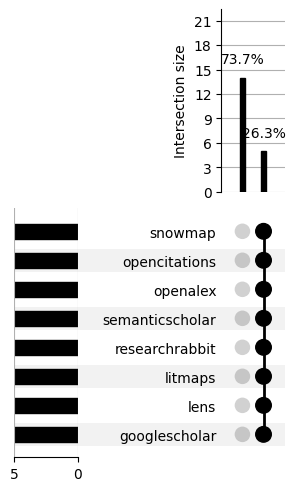

In [ ]:
upset_from_global_presence(global_presence_slr3, "")

### **ARTIGO 04**

In [ ]:
#ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/CSVs gerados pelas plataformas/new_csvs_slr04/seed_studies04")
ROOT = CSV_BASE / "new_csvs_slr04/seed_studies04"

gt_df_slr4, presence_by_seed_slr4, summary_slr4 = run_slr_seed_structure(
    root_path=ROOT,
    gt_filename="g-t_artigo04.csv",
    verbose=True
)

display(gt_df_slr4.head())
display(summary_slr4)
display(presence_by_seed_slr4["artigo01_04"])
display(presence_by_seed_slr4["artigo02_04"])
display(presence_by_seed_slr4["artigo03_04"])
display(presence_by_seed_slr4["artigo05_04"])
display(presence_by_seed_slr4["artigo06_04"])
display(presence_by_seed_slr4["artigo07_04"])
display(presence_by_seed_slr4["artigo08_04"])
display(presence_by_seed_slr4["artigo09_04"])
display(presence_by_seed_slr4["artigo11_04"])
display(presence_by_seed_slr4["artigo12_04"])
display(presence_by_seed_slr4["artigo13_04"])
display(presence_by_seed_slr4["artigo14_04"])
display(presence_by_seed_slr4["artigo15_04"])


,Title,Doi,doi_norm,title_norm,uid
0,The learning effect on organizational performa...,10.1108/EJMBE-03-2021-0107,10.1108/ejmbe-03-2021-0107,the learning effect on organizational performa...,10.1108/ejmbe-03-2021-0107
1,Towards an effective approach for architectura...,doi.org/10.1504/IJGUC.2020.110908,10.1504/ijguc.2020.110908,towards an effective approach for architectura...,10.1504/ijguc.2020.110908
2,Socio-Technical Challenges Inhibiting Effectiv...,NaN,None,sociotechnical challenges inhibiting effective...,sociotechnical challenges inhibiting effective...
3,Influencing factors on knowledge sharing in vi...,doi.org/10.3233/WOR-2112,10.3233/wor-2112,influencing factors on knowledge sharing in vi...,10.3233/wor-2112
4,Perceptions of knowledge management in Brazili...,doi.org/10.5753/cibse.2022.20975,10.5753/cibse.2022.20975,perceptions of knowledge management in brazili...,10.5753/cibse.2022.20975


,folder,file,tool,gt_total,tool_total_raw,match_doi,match_title_only,match_total,seed
0,artigo01_04,googleScholar01_04.csv,googlescholar,10,31,0,0,0,artigo01_04
1,artigo01_04,lens01_04.csv,lens,10,14,0,0,0,artigo01_04
2,artigo01_04,litmap01_04.csv,litmaps,10,19,0,0,0,artigo01_04
3,artigo01_04,openAlex01_04.csv,openalex,10,16,0,0,0,artigo01_04
4,artigo01_04,openCitations01_04.csv,opencitations,10,14,0,0,0,artigo01_04
...,...,...,...,...,...,...,...,...,...
97,artigo15_04,openAlex15_04.csv,openalex,10,8,0,0,0,artigo15_04
98,artigo15_04,openCitations15_04.csv,opencitations,10,6,0,0,0,artigo15_04
99,artigo15_04,our_tool15_04.csv,snowmap,10,10,0,0,0,artigo15_04
100,artigo15_04,researchRabbit15_04.csv,researchrabbit,10,10,0,0,0,artigo15_04


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.ijin.2021.09.004,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,True,False,True,True,True,True,False,True
10.1504/ijguc.2020.110908,True,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,True,False,False,False,False,False,False,False
10.3233/wor-2112,True,True,True,True,True,True,False,True
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.ijin.2021.09.004,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,True,False,True,True,True,True,False,True
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.ijin.2021.09.004,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False


...

,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.ijin.2021.09.004,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.ijin.2021.09.004,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,True,True,True,True,True,True,True,True


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.ijin.2021.09.004,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,False,False,False,False,False,False,False,False
10.1016/j.ijin.2021.09.004,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,False,False,False,False,False,False,False,False
10.1504/ijguc.2020.110908,False,False,False,False,False,False,False,False
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,False,False,False,False,False,False,False,False
10.3233/wor-2112,False,False,False,False,False,False,False,False
10.5753/cibse.2022.20975,False,False,False,False,False,False,False,False
10.1007/978-3-030-85990-9_59,False,False,False,False,False,False,False,False
10.1109/tii.2020.2990953,True,False,False,False,False,False,False,False
10.1016/j.ijin.2021.09.004,False,False,False,False,False,False,False,False
10.1016/j.jss.2022.111572,False,False,False,False,False,False,False,False


In [ ]:
global_presence_slr4 = None

for seed, df in presence_by_seed_slr4.items():
    df_bin = df[ALL_TOOLS].astype(bool)
    global_presence_slr4 = df_bin.copy() if global_presence_slr4 is None else (global_presence_slr4 | df_bin)

global_presence_slr4 = global_presence_slr4.astype(int)
display(global_presence_slr4)

,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1108/ejmbe-03-2021-0107,1,0,1,1,1,1,0,1
10.1504/ijguc.2020.110908,1,0,0,0,0,0,0,0
sociotechnical challenges inhibiting effective knowledge sharing among ict workers in underresourced egovernment project teams,1,0,0,0,0,0,0,0
10.3233/wor-2112,1,1,1,1,1,1,0,1
10.5753/cibse.2022.20975,1,0,1,1,1,1,0,1
10.1007/978-3-030-85990-9_59,1,1,1,1,0,1,1,0
10.1109/tii.2020.2990953,1,0,0,0,0,0,0,0
10.1016/j.ijin.2021.09.004,0,0,0,0,0,0,0,0
10.1016/j.jss.2022.111572,1,1,1,1,1,1,1,1


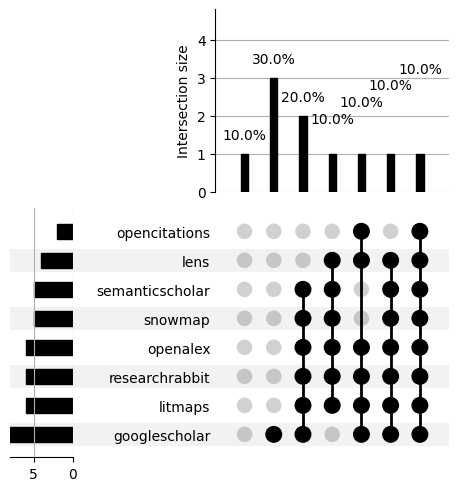

In [ ]:

upset_from_global_presence(global_presence_slr4, "")

### **ARTIGO 01**

In [ ]:
#ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/CSVs gerados pelas plataformas/new_csvs_slr01")
ROOT = CSV_BASE / "new_csvs_slr01/seed_studies01"

gt_df_slr1, presence_slr1, summary_slr1 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo01.csv",
    verbose=True
)

display(gt_df_slr1)
display(summary_slr1)
display(presence_slr1)

,Title,Doi,doi_norm,title_norm,uid
0,Transfer learning across variants and versions...,https://doi.org/10.1109/TSE.2021.3116768,10.1109/tse.2021.3116768,transfer learning across variants and versions...,10.1109/tse.2021.3116768
1,On Programming Variability with Large Language...,https://doi.org/10.1145/3579027.3608972,10.1145/3579027.3608972,on programming variability with large language...,10.1145/3579027.3608972
2,Adaptive behavioral model learning for softwar...,https://doi.org/10.1145/3546932.3546991,10.1145/3546932.3546991,adaptive behavioral model learning for softwar...,10.1145/3546932.3546991
3,A Monte Carlo tree search conceptual framework...,https://doi.org/10.1016/j.jss.2022.111551,10.1016/j.jss.2022.111551,a monte carlo tree search conceptual framework...,10.1016/j.jss.2022.111551
4,CoMSA: A Modeling-Driven Sampling Approach for...,https://doi.org/10.1109/ASE56229.2023.00091,10.1109/ase56229.2023.00091,comsa a modelingdriven sampling approach for c...,10.1109/ase56229.2023.00091
5,Configuration optimization with limited functi...,https://doi.org/10.1007/978-3-031-34560-9_4,10.1007/978-3-031-34560-9_4,configuration optimization with limited functi...,10.1007/978-3-031-34560-9_4
6,"Optimization Space Learning: A Lightweight, No...",https://doi.org/10.1145/3646548.3672588,10.1145/3646548.3672588,optimization space learning a lightweight noni...,10.1145/3646548.3672588
7,Pragmatic Random Sampling of the Linux Kernel:...,https://doi.org/10.1145/3646548.3672586,10.1145/3646548.3672586,pragmatic random sampling of the linux kernel ...,10.1145/3646548.3672586
8,Out-of-the-Box Prediction of Non-Functional Va...,https://doi.org/10.1145/3646548.3676546,10.1145/3646548.3676546,outofthebox prediction of nonfunctional varian...,10.1145/3646548.3676546
9,Specialization of run-time configuration space...,https://doi.org/10.1145/3555776.3578613,10.1145/3555776.3578613,specialization of runtime configuration space ...,10.1145/3555776.3578613


,folder,file,tool,gt_total,tool_total_raw,match_doi,match_title_only,match_total
0,new_csvs_slr01,artigo01_GoogleAcademico.csv,googlescholar,24,117,9,14,23
1,new_csvs_slr01,artigo01_Lens.csv,lens,24,56,14,0,14
2,new_csvs_slr01,artigo01_litmaps.csv,litmaps,24,91,14,1,15
3,new_csvs_slr01,artigo01_openAlex.csv,openalex,24,68,15,0,15
4,new_csvs_slr01,artigo01_openCitations.csv,opencitations,24,35,11,0,11
5,new_csvs_slr01,artigo01_researchRabbit.csv,researchrabbit,24,111,0,16,16
6,new_csvs_slr01,artigo01_semanticscholar.csv,semanticscholar,24,92,14,1,15
7,new_csvs_slr01,artigo01_snowmap.csv,snowmap,24,94,14,1,15


,googlescholar,lens,litmaps,researchrabbit,semanticscholar,openalex,opencitations,snowmap
gt_record,,,,,,,,
10.1109/tse.2021.3116768,True,True,True,True,True,True,True,True
10.1145/3579027.3608972,True,True,True,True,True,True,True,True
10.1145/3546932.3546991,True,True,True,True,True,True,True,True
10.1016/j.jss.2022.111551,True,False,False,False,False,False,False,False
10.1109/ase56229.2023.00091,True,True,True,True,True,True,False,True
10.1007/978-3-031-34560-9_4,True,True,True,True,False,True,True,False
10.1145/3646548.3672588,True,True,False,True,True,True,True,True
10.1145/3646548.3672586,True,True,True,True,True,True,True,True
10.1145/3646548.3676546,True,True,False,True,True,True,True,True


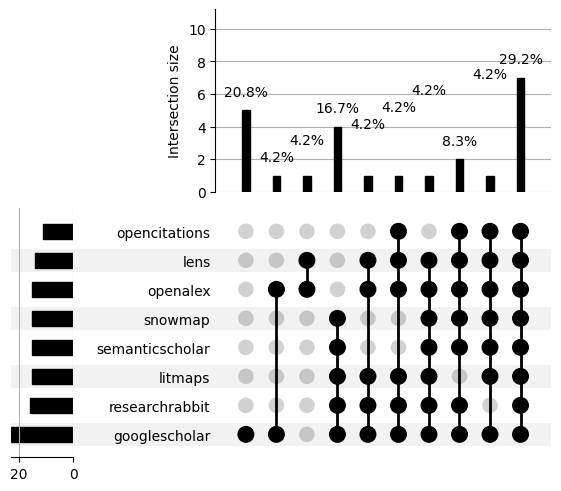

In [ ]:
upset_from_global_presence(presence_slr1, "")

computar as métricas

In [ ]:
def match_gt_against_tool_with_uids(
    gt_df: pd.DataFrame,
    tool_df: pd.DataFrame,
    threshold: float = 0.90
):
    gt = gt_df.copy()
    tool = tool_df.copy()

    gt["title_norm"] = gt["title_norm"].fillna("")
    tool["title_norm"] = tool["title_norm"].fillna("")

    match_doi = [False] * len(gt)
    match_title = [False] * len(gt)
    found = [False] * len(gt)
    matched_tool_uids = set()

    # DOI
    tool_doi_to_uid = (
        tool.loc[tool["doi_norm"].notna(), ["doi_norm", "uid"]]
        .drop_duplicates()
        .set_index("doi_norm")["uid"]
        .to_dict()
    )

    matched_dois = set()

    for i, row in gt.iterrows():
        doi = row["doi_norm"]
        if pd.notna(doi) and doi in tool_doi_to_uid:
            match_doi[i] = True
            found[i] = True
            matched_dois.add(doi)
            matched_tool_uids.add(tool_doi_to_uid[doi])

    # fuzzy title
    tool_remaining = tool[~tool["doi_norm"].isin(matched_dois)].copy()
    used_tool_idx = set()

    for i, row in gt.iterrows():
        if found[i]:
            continue

        gtitle = row["title_norm"]
        if not gtitle:
            continue

        best_score = -1
        best_j = None

        for j, trow in tool_remaining.iterrows():
            if j in used_tool_idx:
                continue

            ttitle = trow["title_norm"]
            if not ttitle:
                continue

            s = fuzzy_match_score(gtitle, ttitle)
            if s > best_score:
                best_score = s
                best_j = j

        if best_j is not None and best_score >= threshold:
            match_title[i] = True
            found[i] = True
            used_tool_idx.add(best_j)
            matched_tool_uids.add(tool_remaining.loc[best_j, "uid"])

    match_df = pd.DataFrame({
        "match_doi": match_doi,
        "match_title": match_title,
        "found": found
    }, index=gt.index)

    return match_df, matched_tool_uids

In [ ]:
def compute_metrics(
    gt_df: pd.DataFrame,
    tool_df: pd.DataFrame,
    threshold: float = 0.90,
    tool_name: Optional[str] = None
) -> dict:
    gt = prepare_matching_dataframe(gt_df, tool=None)
    tool = prepare_matching_dataframe(tool_df, tool=tool_name)

    match_df, matched_tool_uids = match_gt_against_tool_with_uids(
        gt, tool, threshold=threshold
    )

    tp = int(match_df["found"].sum())
    fn = len(gt) - tp

    tool_uid_set = set(tool["uid"].dropna())
    fp = len(tool_uid_set - matched_tool_uids)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "gt_size": len(gt),
        "tool_unique_size": len(tool_uid_set),
        "doi_matches": int(match_df["match_doi"].sum()),
        "title_matches": int(match_df["match_title"].sum()),
    }

In [ ]:
from pathlib import Path
import pandas as pd

ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/CSVs gerados pelas plataformas/new_csvs_slr01")

gt_df_slr1, presence_slr1, summary_slr1 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo01.csv",
    verbose=True
)

slr = ROOT.name
gt = gt_df_slr1

linhas = []

for csv_path in sorted(ROOT.glob("*.csv")):
    if csv_path.name == "g-t_artigo01.csv":
        continue

    ferramenta = detect_tool_from_filename(csv_path)

    if ferramenta is None:
        #print(f"Ferramenta não reconhecida para arquivo: {csv_path.name}")
        continue

    df_tool = pd.read_csv(csv_path)

    m = compute_metrics(
        gt_df=gt,
        tool_df=df_tool,
        threshold=0.85,
        tool_name=ferramenta
    )

    linhas.append({
        "SLR": slr,
        "Ferramenta": ferramenta,
        "Arquivo": csv_path.name,
        "TP": m["tp"],
        "FP": m["fp"],
        "FN": m["fn"],
        "Precision": round(m["precision"], 2),
        "Recall": round(m["recall"], 2),
        "F1": round(m["f1"], 2),
        "DOI_matches": m["doi_matches"],
        "Title_matches": m["title_matches"],
        "GT_n": m["gt_size"],
        "Tool_unique_n": m["tool_unique_size"],
    })

tabela = pd.DataFrame(linhas).sort_values(
    ["F1", "Recall", "Precision"],
    ascending=False
).reset_index(drop=True)

tabela

,SLR,Ferramenta,Arquivo,TP,FP,FN,Precision,Recall,F1,DOI_matches,Title_matches,GT_n,Tool_unique_n
0,new_csvs_slr01,opencitations,artigo01_openCitations.csv,11,24,13,0.31,0.46,0.37,11,0,24,35
1,new_csvs_slr01,lens,artigo01_Lens.csv,14,42,10,0.25,0.58,0.35,14,0,24,56
2,new_csvs_slr01,googlescholar,artigo01_GoogleAcademico.csv,24,95,0,0.20,1.00,0.34,9,15,24,119
3,new_csvs_slr01,openalex,artigo01_openAlex.csv,15,53,9,0.22,0.62,0.33,15,0,24,68
4,new_csvs_slr01,litmaps,artigo01_litmaps.csv,15,71,9,0.17,0.62,0.27,14,1,24,86
5,new_csvs_slr01,researchrabbit,artigo01_researchRabbit.csv,16,85,8,0.16,0.67,0.26,0,16,24,101
6,new_csvs_slr01,semanticscholar,artigo01_semanticscholar.csv,15,81,9,0.16,0.62,0.25,14,1,24,96
7,new_csvs_slr01,snowmap,artigo01_snowmap.csv,15,83,9,0.15,0.62,0.25,14,1,24,98


In [ ]:
from pathlib import Path
import pandas as pd
from collections import defaultdict

def run_slr02_with_duplicates(root_path, gt_df, threshold=0.85):
    """
    Avaliação SLR2 sem remover duplicatas.
    Mantém todos os artigos mesmo se aparecerem múltiplas vezes.
    """

    slr = root_path.parent.name
    linhas = []

    # 🔵 1. Agrupar resultados por ferramenta
    tool_dfs = defaultdict(list)

    for seed_dir in sorted(root_path.iterdir()):
        if seed_dir.is_dir() and seed_dir.name.lower().startswith("artigo"):

            for csv_path in sorted(seed_dir.glob("*.csv")):

                ferramenta = detect_tool_from_filename(csv_path)
                if ferramenta is None:
                    continue

                df_tool = pd.read_csv(csv_path)
                tool_dfs[ferramenta].append(df_tool)

    # 🔵 2. Consolidar (sem remover duplicatas)
    tool_consolidated = {ferramenta: pd.concat(dfs, ignore_index=True)
                         for ferramenta, dfs in tool_dfs.items()}

    # 🔵 3. Calcular métricas
    for ferramenta, df_tool in tool_consolidated.items():

        m = compute_metrics(
            gt_df=gt_df,
            tool_df=df_tool,
            threshold=threshold,
            tool_name=ferramenta
        )

        linhas.append({
            "SLR": slr,
            "Ferramenta": ferramenta,
            "Arquivo": "consolidado",
            "TP": m["tp"],
            "FP": m["fp"],
            "FN": m["fn"],
            "Precision": round(m["precision"], 2),
            "Recall": round(m["recall"], 2),
            "F1": round(m["f1"], 2),
            "DOI_matches": m["doi_matches"],
            "Title_matches": m["title_matches"],
            "GT_n": m["gt_size"],
            "Tool_unique_n": len(df_tool),  # agora conta todas as linhas
        })

    tabela = pd.DataFrame(linhas).sort_values(
        ["F1", "Recall", "Precision"],
        ascending=False
    ).reset_index(drop=True)

    return tabela

In [ ]:
ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/CSVs gerados pelas plataformas/new_csvs_slr02/seed_studies02")

# Carrega o GT do SLR2
gt_df_slr2, presence_slr2, summary_slr2 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo02.csv",
    verbose=True
)
tabela_slr2 = run_slr02_with_duplicates(
    root_path=ROOT,
    gt_df=gt_df_slr2,
    threshold=0.85  # limiar de correspondência
)
# Mostra a tabela final
tabela_slr2

,SLR,Ferramenta,Arquivo,TP,FP,FN,Precision,Recall,F1,DOI_matches,Title_matches,GT_n,Tool_unique_n
0,new_csvs_slr02,snowmap,consolidado,2,141,3,0.01,0.4,0.03,0,2,5,171
1,new_csvs_slr02,researchrabbit,consolidado,2,144,3,0.01,0.4,0.03,0,2,5,185
2,new_csvs_slr02,semanticscholar,consolidado,2,137,3,0.01,0.4,0.03,0,2,5,185
3,new_csvs_slr02,lens,consolidado,2,209,3,0.01,0.4,0.02,0,2,5,235
4,new_csvs_slr02,litmaps,consolidado,2,248,3,0.01,0.4,0.02,0,2,5,290
5,new_csvs_slr02,googlescholar,consolidado,2,358,3,0.01,0.4,0.01,0,2,5,429
6,new_csvs_slr02,openalex,consolidado,1,208,4,0.00,0.2,0.01,0,1,5,231
7,new_csvs_slr02,opencitations,consolidado,0,140,5,0.00,0.0,0.00,0,0,5,156


In [ ]:
ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/CSVs gerados pelas plataformas/new_csvs_slr03/seed_studies03")

# Carrega o GT do SLR2
gt_df_slr2, presence_slr2, summary_slr2 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo03.csv",
    verbose=True
)
tabela_slr2 = run_slr02_with_duplicates(
    root_path=ROOT,
    gt_df=gt_df_slr2,
    threshold=0.85  # limiar de correspondência
)
# Mostra a tabela final
tabela_slr2

,SLR,Ferramenta,Arquivo,TP,FP,FN,Precision,Recall,F1,DOI_matches,Title_matches,GT_n,Tool_unique_n
0,new_csvs_slr03,semanticscholar,consolidado,5,22,14,0.19,0.26,0.22,0,5,19,28
1,new_csvs_slr03,snowmap,consolidado,5,91,14,0.05,0.26,0.09,5,0,19,100
2,new_csvs_slr03,litmaps,consolidado,5,135,14,0.04,0.26,0.06,5,0,19,144
3,new_csvs_slr03,researchrabbit,consolidado,5,140,14,0.03,0.26,0.06,0,5,19,166
4,new_csvs_slr03,lens,consolidado,5,167,14,0.03,0.26,0.05,5,0,19,177
5,new_csvs_slr03,openalex,consolidado,5,183,14,0.03,0.26,0.05,5,0,19,188
6,new_csvs_slr03,googlescholar,consolidado,5,221,14,0.02,0.26,0.04,0,5,19,227
7,new_csvs_slr03,opencitations,consolidado,5,850,14,0.01,0.26,0.01,5,0,19,857


In [ ]:
ROOT = Path("/content/drive/MyDrive/estudos_snowbaling/CSVs gerados pelas plataformas/new_csvs_slr04/seed_studies04")

# Carrega o GT do SLR2
gt_df_slr2, presence_slr2, summary_slr2 = run_slr01(
    root_path=ROOT,
    gt_filename="g-t_artigo04.csv",
    verbose=True
)
tabela_slr2 = run_slr02_with_duplicates(
    root_path=ROOT,
    gt_df=gt_df_slr2,
    threshold=0.85  # limiar de correspondência
)
# Mostra a tabela final
tabela_slr2

,SLR,Ferramenta,Arquivo,TP,FP,FN,Precision,Recall,F1,DOI_matches,Title_matches,GT_n,Tool_unique_n
0,new_csvs_slr04,researchrabbit,consolidado,6,120,4,0.05,0.6,0.09,0,6,10,148
1,new_csvs_slr04,openalex,consolidado,6,126,4,0.05,0.6,0.08,5,1,10,147
2,new_csvs_slr04,litmaps,consolidado,6,132,4,0.04,0.6,0.08,5,1,10,158
3,new_csvs_slr04,lens,consolidado,4,92,6,0.04,0.4,0.08,3,1,10,110
4,new_csvs_slr04,googlescholar,consolidado,9,232,1,0.04,0.9,0.07,0,9,10,266
5,new_csvs_slr04,snowmap,consolidado,5,124,5,0.04,0.5,0.07,4,1,10,143
6,new_csvs_slr04,semanticscholar,consolidado,5,132,5,0.04,0.5,0.07,0,5,10,154
7,new_csvs_slr04,opencitations,consolidado,2,68,8,0.03,0.2,0.05,2,0,10,83
